In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [3]:
x, y = make_circles(n_samples=100, noise=0.1, random_state=1)

<Axes: >

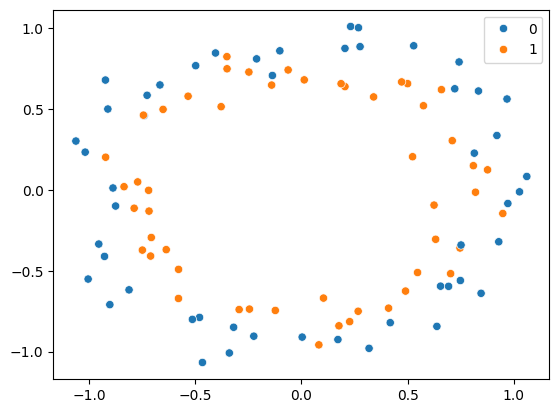

In [5]:
sns.scatterplot(x = x[:,0],y = x[:,1],hue=y)

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [10]:
model = Sequential()

model.add(Dense(256, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

In [11]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [13]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=3500, verbose=0)

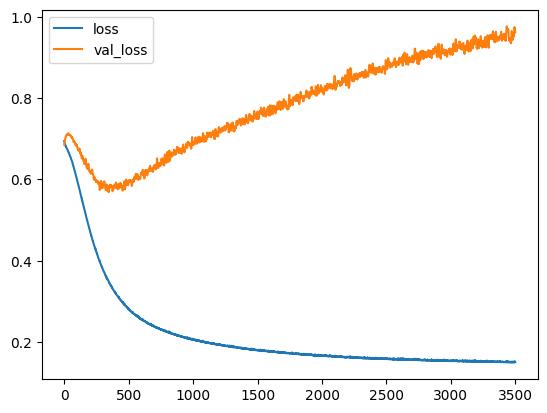

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step


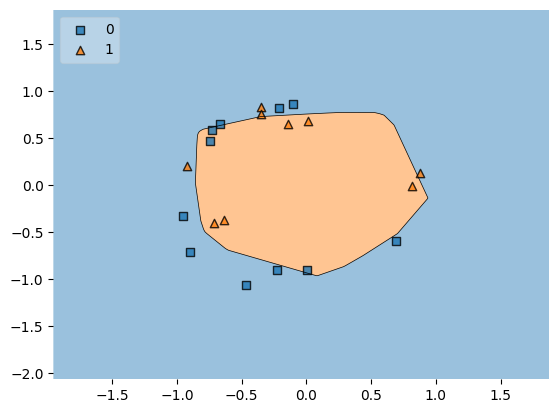

In [16]:
plot_decision_regions(x_test, y_test, clf=model, legend=2)
plt.show()

# Early Stopping

In [29]:
model = Sequential()

model.add(Dense(256, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

In [30]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [34]:
callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.00001,
    patience=100,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
)

In [35]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=3500, verbose=0, callbacks=callback)

Epoch 465: early stopping


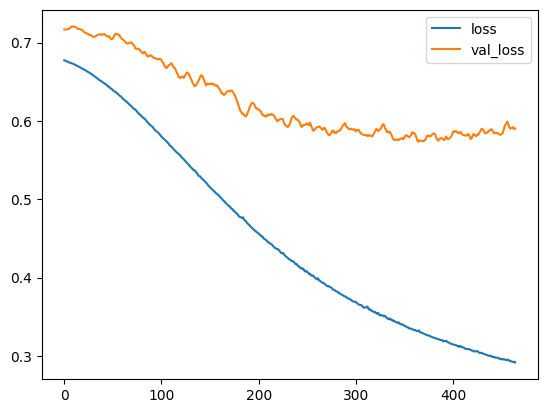

In [36]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.show()